In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt
import xgboost as xgb
from catboost import CatBoostRegressor
import joblib


In [2]:
# Visualization style settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [3]:
import opendatasets as od

In [4]:
dataset = "https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data?select=test.csv"

In [5]:
od.download(dataset)

Skipping, found downloaded files in ".\store-sales-time-series-forecasting" (use force=True to force download)


In [6]:
import os

In [7]:
data_dir = r'.\store-sales-time-series-forecasting'

In [8]:
import os

corrected_path = r".\store-sales-time-series-forecasting"

if os.path.exists(corrected_path):
    print(os.listdir(corrected_path))
else:
    print(f"Path {corrected_path} does not exist")

['holidays_events.csv', 'oil.csv', 'sample_submission.csv', 'stores.csv', 'test.csv', 'train.csv', 'transactions.csv']


In [9]:
 #Load data
data_dir = r".\store-sales-time-series-forecasting"

train_df = pd.read_csv(f"{data_dir}/train.csv")
test_df = pd.read_csv(f"{data_dir}/test.csv")
oil_df = pd.read_csv(f"{data_dir}/oil.csv")
stores_df = pd.read_csv(f"{data_dir}/stores.csv")
transactions_df = pd.read_csv(f"{data_dir}/transactions.csv")
holidays_events_df = pd.read_csv(f"{data_dir}/holidays_events.csv")
sample_submission_df = pd.read_csv(f"{data_dir}/sample_submission.csv")

In [10]:
# Convert dates
for df in [train_df, test_df, oil_df, transactions_df, holidays_events_df]:
    df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully")

Data loaded successfully


In [11]:
# Feature Engineering Function
def create_features(df, is_train=True):
    """Create features for store sales prediction"""
    df = df.copy()
    
    # Time features
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['quarter'] = df['date'].dt.quarter
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    # Day of year (cyclic encoding)
    df['dayofyear'] = df['date'].dt.dayofyear
    df['sin_dayofyear'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_dayofyear'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
    
    # Month cyclic encoding
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Day of week cyclic encoding
    df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    return df

# Process training data
print("Processing training data...")
train = create_features(train_df, is_train=True)

# Merge with stores
train = train.merge(stores_df, on='store_nbr', how='left')

# Merge with transactions
train = train.merge(transactions_df, on=['date', 'store_nbr'], how='left')

# Handle oil prices
oil_df['dcoilwtico'] = oil_df['dcoilwtico'].fillna(method='ffill').fillna(method='bfill')
train = train.merge(oil_df, on='date', how='left')
train['dcoilwtico'] = train['dcoilwtico'].fillna(train['dcoilwtico'].median())

# Process holidays
holiday_flags = holidays_events_df.groupby('date').agg(
    is_holiday=('type', lambda x: 1 if any(t in ['Holiday', 'Event'] for t in x) else 0),
    holiday_count=('description', 'count')
).reset_index()

train = train.merge(holiday_flags, on='date', how='left')
train['is_holiday'] = train['is_holiday'].fillna(0)
train['holiday_count'] = train['holiday_count'].fillna(0)

# Fill missing values
train['onpromotion'] = train['onpromotion'].fillna(0)
train['transactions'] = train.groupby('store_nbr')['transactions'].transform(lambda x: x.fillna(x.median()))
train['transactions'] = train['transactions'].fillna(train['transactions'].median())

# Label encoding for categorical variables
categorical_cols = ['family', 'city', 'state', 'type', 'cluster']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    train[f'{col}_encoded'] = le.fit_transform(train[col].astype(str))
    label_encoders[col] = le

print("Training data processed")

Processing training data...
Training data processed


In [12]:
# Create lag features for time series
print("Creating lag features...")
train = train.sort_values(['store_nbr', 'family', 'date'])

# Lag features (using previous days' sales)
for lag in [1, 7, 14, 21, 28]:
    train[f'sales_lag_{lag}'] = train.groupby(['store_nbr', 'family'])['sales'].shift(lag)

# Rolling statistics
for window in [7, 14, 28, 60]:
    train[f'sales_rolling_mean_{window}'] = train.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    train[f'sales_rolling_std_{window}'] = train.groupby(['store_nbr', 'family'])['sales'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

# Lag features for transactions
for lag in [1, 7, 14]:
    train[f'transactions_lag_{lag}'] = train.groupby(['store_nbr', 'family'])['transactions'].shift(lag)

# Price-related features
train['onpromotion_ratio'] = train.groupby(['store_nbr', 'family'])['onpromotion'].transform(
    lambda x: x.rolling(14, min_periods=1).mean()
)

train = train.fillna(0)
print("Lag features created")

Creating lag features...
Lag features created


In [13]:
# Prepare features
print("Preparing features...")
feature_cols = [
    'store_nbr', 'family_encoded', 'onpromotion', 'transactions', 'dcoilwtico',
    'year', 'month', 'day', 'dayofweek', 'weekofyear', 'quarter', 'is_weekend',
    'is_holiday', 'holiday_count', 'city_encoded', 'state_encoded', 'type_encoded', 
    'cluster_encoded', 'sin_dayofyear', 'cos_dayofyear', 'sin_month', 'cos_month',
    'sin_dayofweek', 'cos_dayofweek', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
    'sales_lag_21', 'sales_lag_28', 'sales_rolling_mean_7', 'sales_rolling_mean_14',
    'sales_rolling_mean_28', 'sales_rolling_mean_60', 'sales_rolling_std_7',
    'sales_rolling_std_14', 'sales_rolling_std_28', 'sales_rolling_std_60',
    'transactions_lag_1', 'transactions_lag_7', 'transactions_lag_14',
    'onpromotion_ratio'
]

X = train[feature_cols]
y = train['sales']

# Handle infinite values
X = X.replace([np.inf, -np.inf], 0)

# Train-validation split (time-based split)
train_sorted = train.sort_values('date')
last_date = train_sorted['date'].max()
val_start_date = last_date - timedelta(days=30)

train_mask = train_sorted['date'] <= val_start_date
val_mask = train_sorted['date'] > val_start_date

X_train = X[train_mask]
y_train = y[train_mask]
X_val = X[val_mask]
y_val = y[val_mask]

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

Preparing features...
Training samples: 2947428
Validation samples: 53460


In [14]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Function to compute RMSLE
def rmsle(y_true, y_pred):
    """Compute Root Mean Squared Logarithmic Error"""
    y_pred = np.maximum(y_pred, 0)  # Ensure non-negative predictions
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

print("Training XGBoost Model...")
# XGBoost with RMSLE objective
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    early_stopping_rounds=50,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=False
)
print("Training CatBoost Model...")
# CatBoost with RMSE objective (works well for sales prediction)
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train_scaled, y_train, eval_set=(X_val_scaled, y_val), early_stopping_rounds=50, verbose=False)

print("Model training complete!")

Training XGBoost Model...
Training CatBoost Model...
Model training complete!


In [15]:
# Make predictions and evaluate
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

# XGBoost predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_val_pred_xgb = xgb_model.predict(X_val_scaled)

# CatBoost predictions
y_train_pred_cat = cat_model.predict(X_train_scaled)
y_val_pred_cat = cat_model.predict(X_val_scaled)

# Ensemble predictions (average of both models)
y_train_pred_ensemble = (y_train_pred_xgb + y_train_pred_cat) / 2
y_val_pred_ensemble = (y_val_pred_xgb + y_val_pred_cat) / 2

# Calculate metrics
models = ['XGBoost', 'CatBoost', 'Ensemble']
train_preds = [y_train_pred_xgb, y_train_pred_cat, y_train_pred_ensemble]
val_preds = [y_val_pred_xgb, y_val_pred_cat, y_val_pred_ensemble]

for name, train_pred, val_pred in zip(models, train_preds, val_preds):
    train_rmsle = rmsle(y_train, train_pred)
    val_rmsle = rmsle(y_val, val_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    val_mae = mean_absolute_error(y_val, val_pred)
    
    print(f"\n{name} Results:")
    print(f"  Train RMSLE: {train_rmsle:.4f}")
    print(f"  Validation RMSLE: {val_rmsle:.4f}")
    print(f"  Train MAE: ${train_mae:.2f}")
    print(f"  Validation MAE: ${val_mae:.2f}")


MODEL EVALUATION

XGBoost Results:
  Train RMSLE: 0.5804
  Validation RMSLE: 0.4491
  Train MAE: $30.83
  Validation MAE: $46.02

CatBoost Results:
  Train RMSLE: 0.9208
  Validation RMSLE: 0.6839
  Train MAE: $41.21
  Validation MAE: $52.97

Ensemble Results:
  Train RMSLE: 0.7624
  Validation RMSLE: 0.5563
  Train MAE: $34.54
  Validation MAE: $47.92


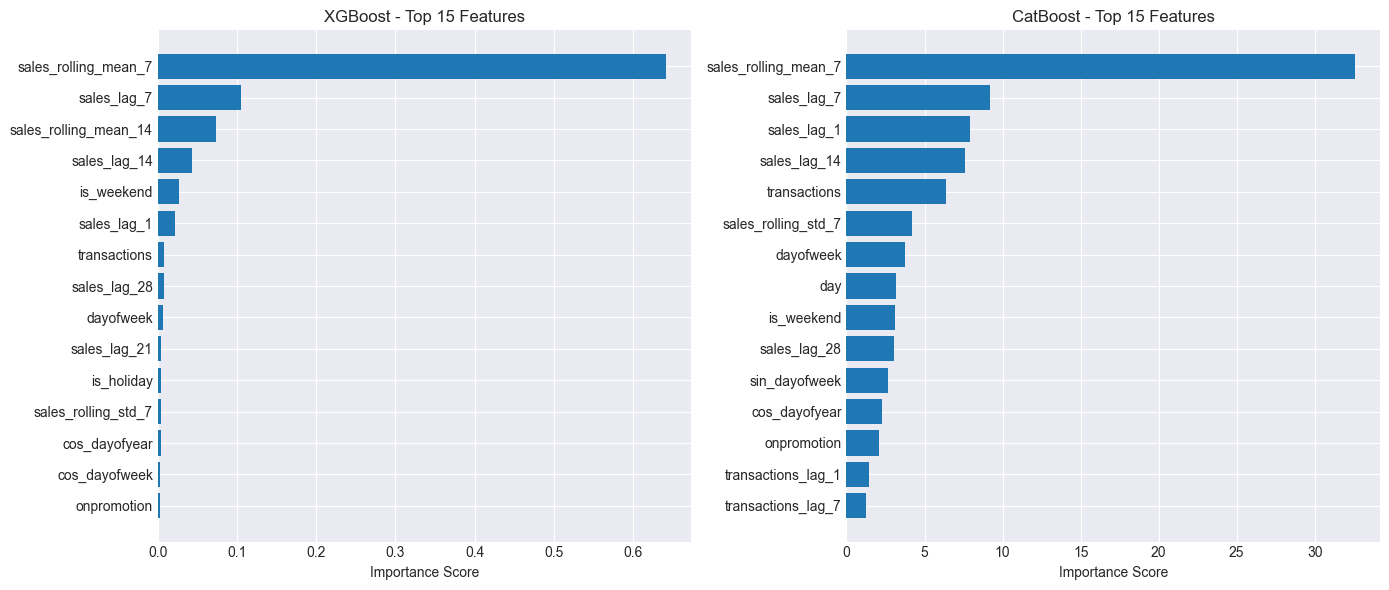

In [16]:
# Feature importance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[0].barh(xgb_importance['feature'], xgb_importance['importance'])
axes[0].set_xlabel('Importance Score')
axes[0].set_title('XGBoost - Top 15 Features')
axes[0].invert_yaxis()

# CatBoost feature importance
cat_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(cat_importance['feature'], cat_importance['importance'])
axes[1].set_xlabel('Importance Score')
axes[1].set_title('CatBoost - Top 15 Features')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

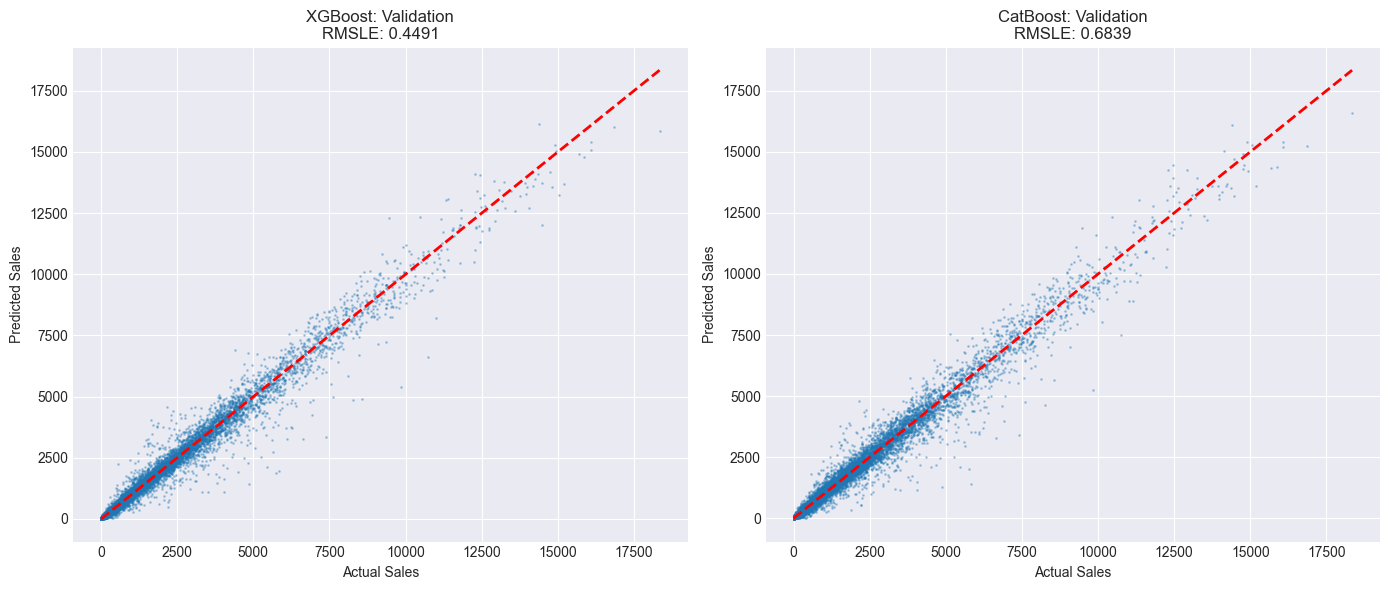

In [17]:
# Actual vs Predicted plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost
axes[0].scatter(y_val, y_val_pred_xgb, alpha=0.3, s=1)
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title(f'XGBoost: Validation\nRMSLE: {rmsle(y_val, y_val_pred_xgb):.4f}')

# CatBoost
axes[1].scatter(y_val, y_val_pred_cat, alpha=0.3, s=1)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title(f'CatBoost: Validation\nRMSLE: {rmsle(y_val, y_val_pred_cat):.4f}')

plt.tight_layout()
plt.show()

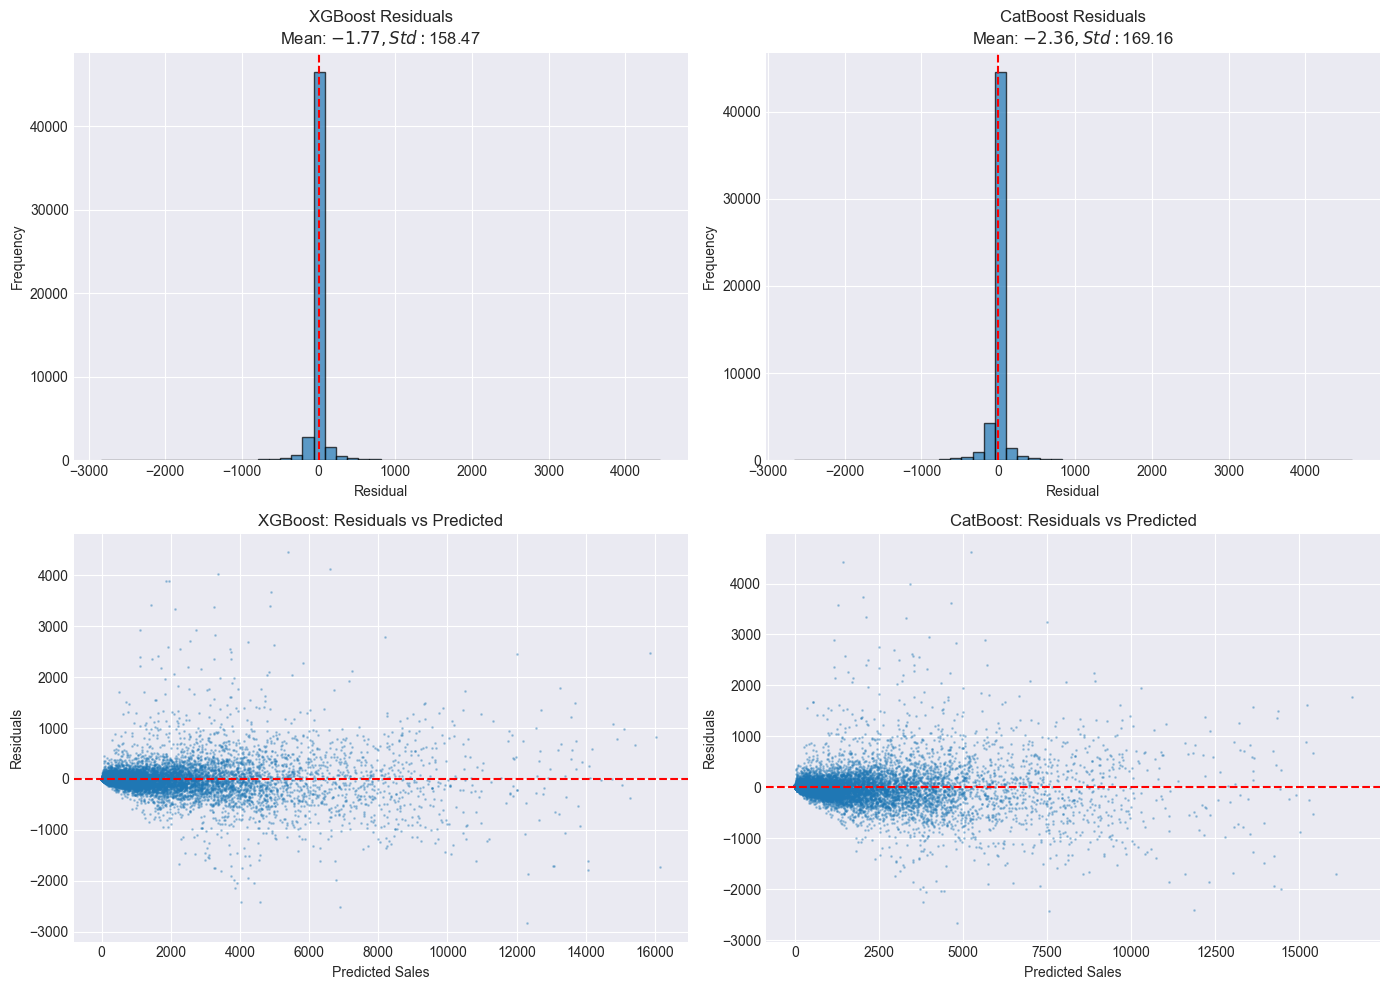

In [18]:
# Residual analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# XGBoost residuals
residuals_xgb = y_val - y_val_pred_xgb
axes[0, 0].hist(residuals_xgb, bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'XGBoost Residuals\nMean: ${residuals_xgb.mean():.2f}, Std: ${residuals_xgb.std():.2f}')

# CatBoost residuals
residuals_cat = y_val - y_val_pred_cat
axes[0, 1].hist(residuals_cat, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'CatBoost Residuals\nMean: ${residuals_cat.mean():.2f}, Std: ${residuals_cat.std():.2f}')

# Residuals vs Predicted - XGBoost
axes[1, 0].scatter(y_val_pred_xgb, residuals_xgb, alpha=0.3, s=1)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Predicted Sales')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('XGBoost: Residuals vs Predicted')

# Residuals vs Predicted - CatBoost
axes[1, 1].scatter(y_val_pred_cat, residuals_cat, alpha=0.3, s=1)
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Predicted Sales')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('CatBoost: Residuals vs Predicted')

plt.tight_layout()
plt.show()

In [19]:
# Save the best model (ensemble predictions for final submission)
print("Generating test predictions...")

# Process test data similarly
test = create_features(test_df, is_train=False)
test = test.merge(stores_df, on='store_nbr', how='left')
test = test.merge(transactions_df, on=['date', 'store_nbr'], how='left')
test = test.merge(oil_df, on='date', how='left')
test['dcoilwtico'] = test['dcoilwtico'].fillna(test['dcoilwtico'].median())
test = test.merge(holiday_flags, on='date', how='left')
test['is_holiday'] = test['is_holiday'].fillna(0)
test['holiday_count'] = test['holiday_count'].fillna(0)

# Fill missing
test['onpromotion'] = test['onpromotion'].fillna(0)
test['transactions'] = test.groupby('store_nbr')['transactions'].transform(lambda x: x.fillna(x.median()))
test['transactions'] = test['transactions'].fillna(test['transactions'].median())

# Encode categorical variables
for col in categorical_cols:
    test[f'{col}_encoded'] = label_encoders[col].transform(test[col].astype(str))

# Create lag features for test (using last available values)
# Use the last week's average as proxy for lag features
last_week_avg = train[train['date'] >= train['date'].max() - timedelta(days=7)]
last_week_avg = last_week_avg.groupby(['store_nbr', 'family_encoded'])['sales'].mean().reset_index()
last_week_avg.columns = ['store_nbr', 'family_encoded', 'avg_sales_last_week']

test = test.merge(last_week_avg, on=['store_nbr', 'family_encoded'], how='left')
test['avg_sales_last_week'] = test['avg_sales_last_week'].fillna(0)

for lag in [1, 7, 14, 21, 28]:
    test[f'sales_lag_{lag}'] = test['avg_sales_last_week']

for window in [7, 14, 28, 60]:
    test[f'sales_rolling_mean_{window}'] = test['avg_sales_last_week']
    test[f'sales_rolling_std_{window}'] = 0

for lag in [1, 7, 14]:
    test[f'transactions_lag_{lag}'] = test['transactions']

test['onpromotion_ratio'] = test['onpromotion']

# Fill remaining NAs
test = test.fillna(0)

# Prepare test features
X_test = test[feature_cols]
X_test_scaled = scaler.transform(X_test)

# Make predictions with ensemble
test_predictions_xgb = xgb_model.predict(X_test_scaled)
test_predictions_cat = cat_model.predict(X_test_scaled)
test_predictions = (test_predictions_xgb + test_predictions_cat) / 2
test_predictions = np.maximum(0, test_predictions)

print(f"Test predictions complete: {len(test_predictions)} predictions")
print(f"Prediction range: ${test_predictions.min():.2f} to ${test_predictions.max():.2f}")
print(f"Average prediction: ${test_predictions.mean():.2f}")

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'sales': test_predictions
})
submission.to_csv('submission_ensemble.csv', index=False)
print("\nSubmission file saved as 'submission_ensemble.csv'")

Generating test predictions...
Test predictions complete: 28512 predictions
Prediction range: $0.00 to $10074.01
Average prediction: $390.05

Submission file saved as 'submission_ensemble.csv'



ERROR ANALYSIS BY SALES RANGE (Ensemble Model)
          absolute_error                 percentage_error actual
                    mean  median     std             mean  count
range                                                           
0-10                3.20    2.27    3.42            71.48  11938
10-50               7.82    5.62    8.40            32.86   9912
50-100             16.75   12.53   16.22            22.95   3309
100-500            34.33   25.03   35.38            14.99  10841
500-1000           80.47   56.99   91.39            11.49   3465
1000-5000         229.72  146.71  277.06            10.33   5112
5000+             546.81  385.66  559.08             7.63   1001


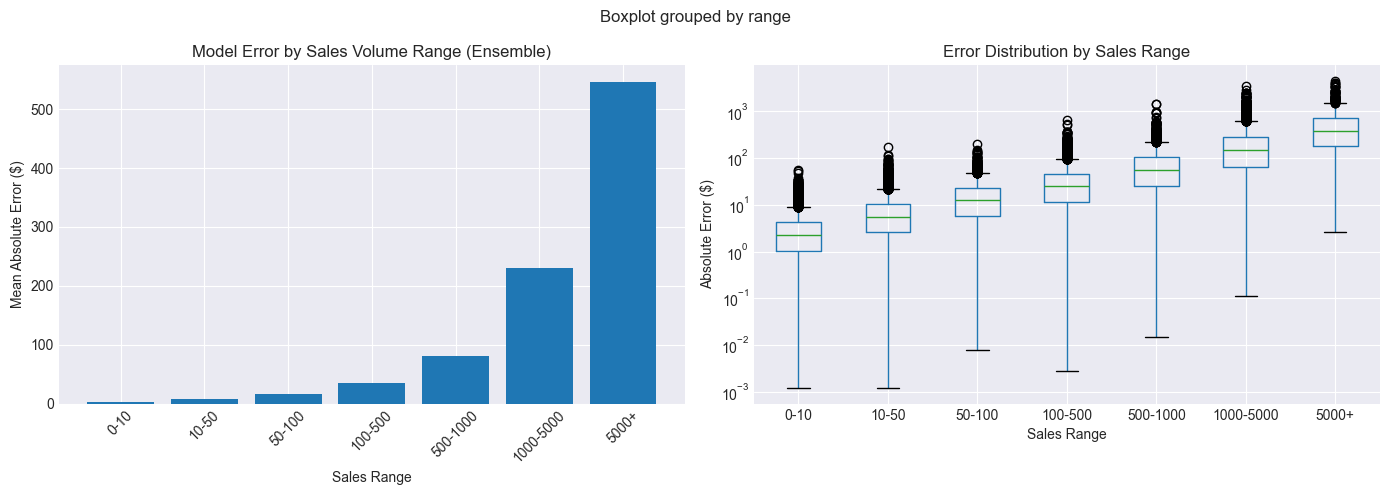

In [20]:
# Error analysis by sales range for the best model
y_val_pred_best = y_val_pred_ensemble  # Using ensemble predictions

bins = [0, 10, 50, 100, 500, 1000, 5000, 100000]
labels = ['0-10', '10-50', '50-100', '100-500', '500-1000', '1000-5000', '5000+']
y_val_binned = pd.cut(y_val, bins=bins, labels=labels)

error_df = pd.DataFrame({
    'actual': y_val,
    'predicted': y_val_pred_best,
    'range': y_val_binned,
    'absolute_error': np.abs(y_val - y_val_pred_best),
    'percentage_error': np.abs((y_val - y_val_pred_best) / (y_val + 1)) * 100
})

range_stats = error_df.groupby('range').agg({
    'absolute_error': ['mean', 'median', 'std'],
    'percentage_error': 'mean',
    'actual': 'count'
}).round(2)

print("\n" + "="*60)
print("ERROR ANALYSIS BY SALES RANGE (Ensemble Model)")
print("="*60)
print(range_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mean_error = error_df.groupby('range')['absolute_error'].mean()
axes[0].bar(range(len(mean_error)), mean_error.values)
axes[0].set_xticks(range(len(mean_error)))
axes[0].set_xticklabels(mean_error.index, rotation=45)
axes[0].set_xlabel('Sales Range')
axes[0].set_ylabel('Mean Absolute Error ($)')
axes[0].set_title('Model Error by Sales Volume Range (Ensemble)')

error_df.boxplot(column='absolute_error', by='range', ax=axes[1])
axes[1].set_xlabel('Sales Range')
axes[1].set_ylabel('Absolute Error ($)')
axes[1].set_title('Error Distribution by Sales Range')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [23]:
# Make predictions with ensemble first, then ensure non-negative
test_predictions_xgb = xgb_model.predict(X_test_scaled)
test_predictions_cat = cat_model.predict(X_test_scaled)
test_predictions_ensemble = (test_predictions_xgb + test_predictions_cat) / 2

# Then apply non-negative constraint
test_predictions_ensemble = np.maximum(0, test_predictions_ensemble)
test_predictions_xgb = np.maximum(0, test_predictions_xgb)
test_predictions_cat = np.maximum(0, test_predictions_cat)

# Create submission DataFrames
submission_ensemble = pd.DataFrame({
    'id': test_df['id'],
    'sales': test_predictions_ensemble
})

submission_xgb = pd.DataFrame({
    'id': test_df['id'],
    'sales': test_predictions_xgb
})

submission_cat = pd.DataFrame({
    'id': test_df['id'],
    'sales': test_predictions_cat
})

# Save files
submission_ensemble.to_csv('submission_ensemble.csv', index=False)
submission_xgb.to_csv('submission_xgboost.csv', index=False)
submission_cat.to_csv('submission_catboost.csv', index=False)

print("Submission files created successfully!")
print(f"Ensemble predictions - Min: ${test_predictions_ensemble.min():.2f}, Max: ${test_predictions_ensemble.max():.2f}")


Submission files created successfully!
Ensemble predictions - Min: $0.00, Max: $10074.01


Ensemble - NaN values: 0
Ensemble - Infinite values: 0


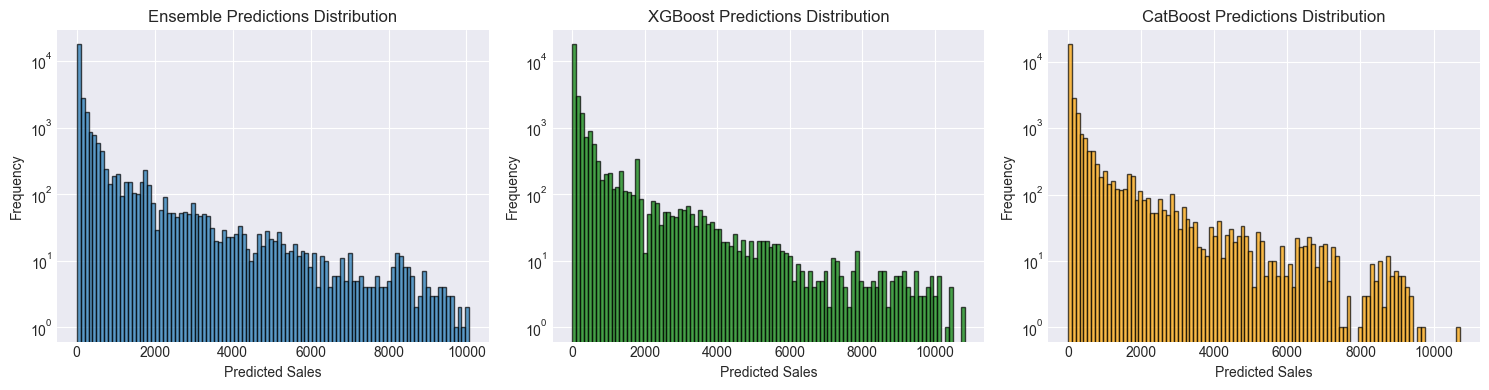

In [24]:
# Check for NaN or infinite values
print(f"Ensemble - NaN values: {np.isnan(test_predictions_ensemble).sum()}")
print(f"Ensemble - Infinite values: {np.isinf(test_predictions_ensemble).sum()}")

# Check prediction distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram of ensemble predictions
axes[0].hist(test_predictions_ensemble, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Predicted Sales')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Ensemble Predictions Distribution')
axes[0].set_yscale('log')

# Histogram of XGBoost predictions
axes[1].hist(test_predictions_xgb, bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Frequency')
axes[1].set_title('XGBoost Predictions Distribution')
axes[1].set_yscale('log')

# Histogram of CatBoost predictions
axes[2].hist(test_predictions_cat, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[2].set_xlabel('Predicted Sales')
axes[2].set_ylabel('Frequency')
axes[2].set_title('CatBoost Predictions Distribution')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [25]:
# Save the trained models for future use
print("\n" + "="*60)
print("SAVING TRAINED MODELS")
print("="*60)

# Save models
joblib.dump(xgb_model, 'xgboost_model_store_sales.pkl')
joblib.dump(cat_model, 'catboost_model_store_sales.pkl')
joblib.dump(scaler, 'scaler_store_sales.pkl')
joblib.dump(label_encoders, 'label_encoders_store_sales.pkl')

print("Models saved successfully:")
print("  - xgboost_model.pkl")
print("  - catboost_model.pkl")
print("  - scaler.pkl")
print("  - label_encoders.pkl")


SAVING TRAINED MODELS
Models saved successfully:
  - xgboost_model.pkl
  - catboost_model.pkl
  - scaler.pkl
  - label_encoders.pkl


In [26]:
# Function to load and use saved models for future predictions
def load_and_predict(new_data_path, model_type='ensemble'):
    """
    Load saved models and make predictions on new data
    
    Parameters:
    new_data_path: path to new test data CSV
    model_type: 'ensemble', 'xgboost', or 'catboost'
    """
    # Load models
    xgb_model_loaded = joblib.load('xgboost_model.pkl')
    cat_model_loaded = joblib.load('catboost_model.pkl')
    scaler_loaded = joblib.load('scaler.pkl')
    label_encoders_loaded = joblib.load('label_encoders.pkl')
    
    # Load new data
    new_test = pd.read_csv(new_data_path)
    new_test['date'] = pd.to_datetime(new_test['date'])
    
    # Process data (simplified version - you'd need full preprocessing)
    print(f"Model loaded. Ready to predict on {len(new_test)} samples")
    
    if model_type == 'xgboost':
        return xgb_model_loaded
    elif model_type == 'catboost':
        return cat_model_loaded
    else:
        # Return both for ensemble
        return xgb_model_loaded, cat_model_loaded

print("\nModel loading function defined. Usage example:")
print("  xgb_model, cat_model = load_and_predict('test.csv', 'ensemble')")


Model loading function defined. Usage example:
  xgb_model, cat_model = load_and_predict('test.csv', 'ensemble')
